# Comparativa de métricas de inferencia

Este notebook compara throughput, latencia, perplejidad y eficiencia
energética entre los modelos disponibles.

**Nota metodológica**: `tokens/s` no es directamente comparable entre
modelos con tokenizers distintos (cada modelo parte el texto de forma
diferente). `words/s` (palabras por segundo) es la métrica "user-perceived"
y sí es honestamente comparable.

In [1]:
"""Carga de todos los runs."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)

# --- Helper para visualización adaptativa ---

def _plot_metric(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
    unit_divisor: float = 1.0,
    unit_label: str = "",
    order: list[str] | None = None,
) -> None:
    """Adaptive visualization based on number of data points per model.

    - n >= 10: histograms with KDE in small multiples (2×2 grid)
    - 3 <= n < 10: stripplot with mean bar, all models together
    - any n: barplot horizontal with error bars and n annotated
    """
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor

    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0

    _order = order or (
        data.groupby("model_label")["_val"]
        .mean().sort_values().index.tolist()
    )
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")

    if min_n >= 10:
        # Histograms with KDE — small multiples
        models = _order
        n_models = len(models)
        ncols = 2
        nrows = (n_models + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(14, 4.5 * nrows), sharey=False)
        axes_flat = list(axes.flatten()) if n_models > 1 else [axes]
        for i, model in enumerate(models):
            ax = axes_flat[i]
            model_data = data[data["model_label"] == model]["_val"]
            n = len(model_data)
            ax.hist(model_data, bins=min(10, n), color=f"C{i}",
                    alpha=0.7, edgecolor="white")
            ax.plot(
                model_data, [0] * n,
                "|", color="black", markersize=14, markeredgewidth=2,
            )
            ax.set_title(f"{model} (n={n})")
            ax.set_xlabel(unit_label or ylabel)
            ax.set_ylabel("Frecuencia")
        for j in range(len(models), len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(full_title, y=1.02)

    elif min_n >= 3:
        # Stripplot with mean bar
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.stripplot(data=data, x="model_label", y="_val",
                      order=_order, jitter=False, size=10,
                      palette="tab10", ax=ax)
        means = data.groupby("model_label")["_val"].mean()
        for i, model in enumerate(_order):
            if model in means.index:
                ax.plot([i - 0.35, i + 0.35],
                        [means[model], means[model]],
                        color="black", lw=2.5, zorder=5)
        # Annotate n
        for i, model in enumerate(_order):
            n = counts.get(model, 0)
            ax.text(i, data[data["model_label"] == model]["_val"].max(),
                    f"n={n}", ha="center", va="bottom", fontsize=9,
                    color="gray")
        ax.set_xlabel("")
        ax.set_ylabel(unit_label or ylabel)
        ax.set_title(full_title)

    else:
        # Barplot horizontal — most honest with n=1
        summary = (
            data.groupby("model_label")["_val"]
            .agg(mean="mean", std="std", n="count")
            .reindex(_order)
            .reset_index()
        )
        fig, ax = plt.subplots(figsize=(10, max(4, len(_order) * 0.8)))
        bars = ax.barh(
            summary["model_label"],
            summary["mean"],
            xerr=summary["std"].fillna(0),
            capsize=4, color="steelblue", alpha=0.8,
        )
        for bar, (_, row) in zip(bars, summary.iterrows()):
            ax.text(
                bar.get_width() * 1.02,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(row['n'])}",
                va="center", fontsize=10, color="gray",
            )
        ax.set_xlabel(unit_label or ylabel)
        ax.set_title(full_title)
        ax.set_ylabel("")

    fig.tight_layout()
    plt.show()

# --- Carga de datos ---

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "raw_runs"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
prompt_df = coll.prompt_metrics_df()
valid = prompt_df[
    (~prompt_df["is_empty_generation"]) &
    (prompt_df["latency_ms"] > 0)
].copy()

print(f"Runs: {prompt_df['run_id'].nunique()}")
print(f"Prompts totales: {len(prompt_df)}, válidos (no vacíos): {len(valid)}")
print(f"Modelos: {', '.join(valid['model_short'].unique())}")

tokenProb size mismatch in run=mnistral prompt=0: got 836 tokens, eval_count=849


Runs: 4
Prompts totales: 10, válidos (no vacíos): 7
Modelos: gemma3n:e2b, granite4:micro-h, ministral-3:3b, tinyllama-1.1b-chat-v1.0.Q4_0


## Throughput: tokens/s y palabras/s

`tokens/s` es la métrica interna del motor. `palabras/s` es lo que percibe
el usuario y es comparable entre modelos con tokenizers distintos.

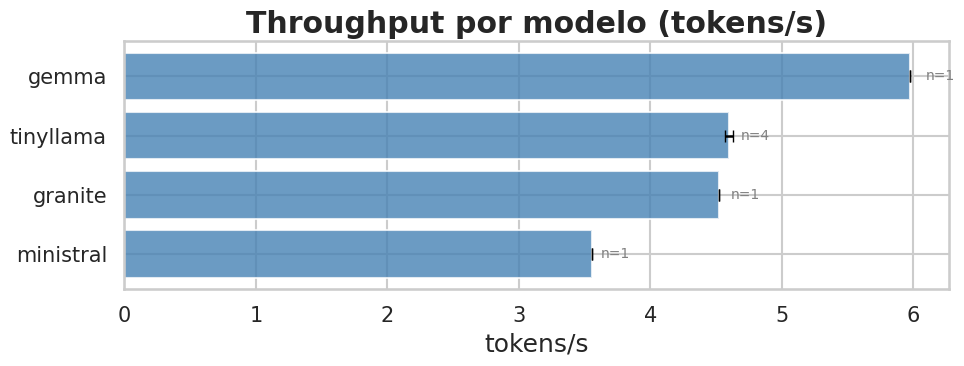

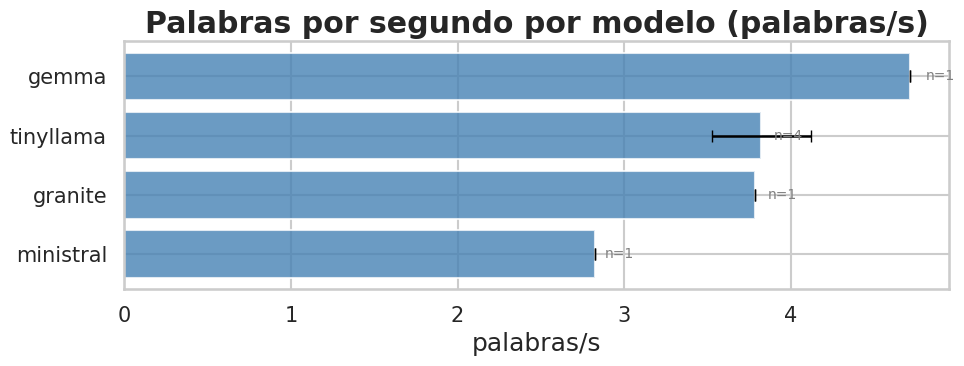

In [2]:
_plot_metric(valid, "tokens_per_second",
             ylabel="tokens/s",
             title="Throughput por modelo",
             unit_label="tokens/s")

_plot_metric(valid, "words_per_second",
             ylabel="palabras/s",
             title="Palabras por segundo por modelo",
             unit_label="palabras/s")


## Latencia

Tiempo total por prompt (carga + prefill + decode + overhead).

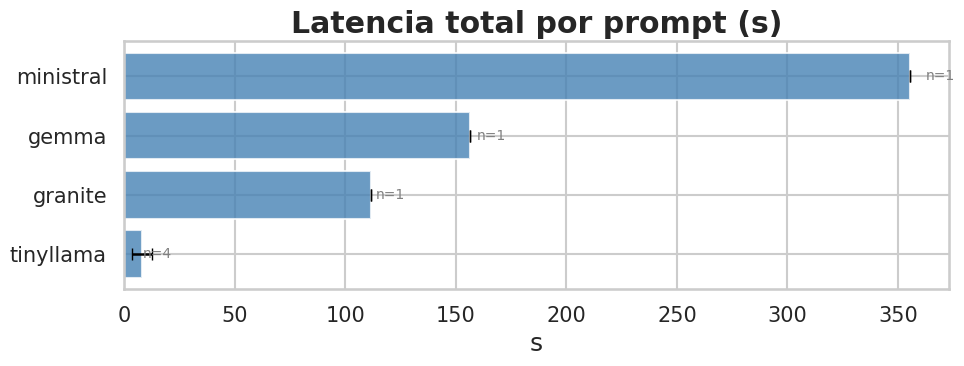

/tmp/ipykernel_413255/1143636191.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")


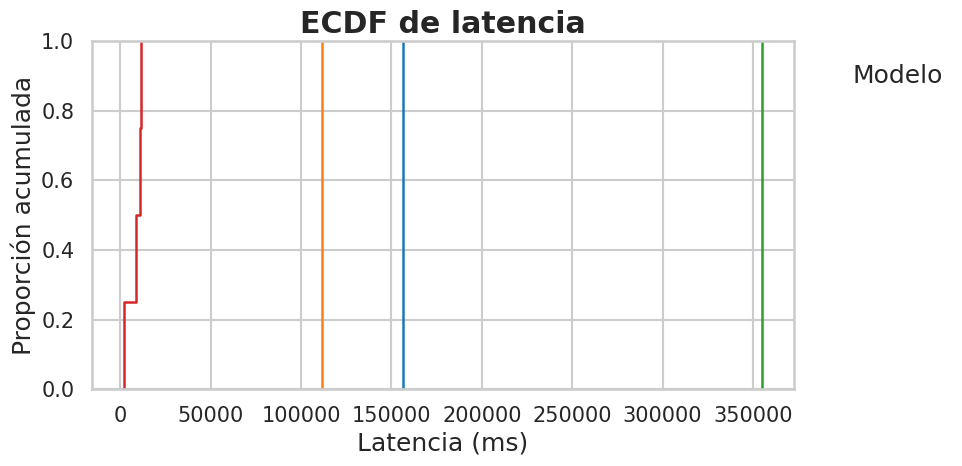

In [3]:
_plot_metric(valid, "latency_ms",
             ylabel="Latencia",
             title="Latencia total por prompt",
             unit_divisor=1000,
             unit_label="s")

# ECDF separado (más legible)
fig, ax = plt.subplots(figsize=(10, 5))
sns.ecdfplot(data=valid, x="latency_ms", hue="model_label", ax=ax)
ax.set_title("ECDF de latencia")
ax.set_xlabel("Latencia (ms)")
ax.set_ylabel("Proporción acumulada")
ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()


## Time to First Token (TTFT)

Tiempo desde que se envía el prompt hasta que llega el primer token
de respuesta. Es `load_duration + prompt_eval_duration`. Métrica
importante para la experiencia de usuario interactiva.

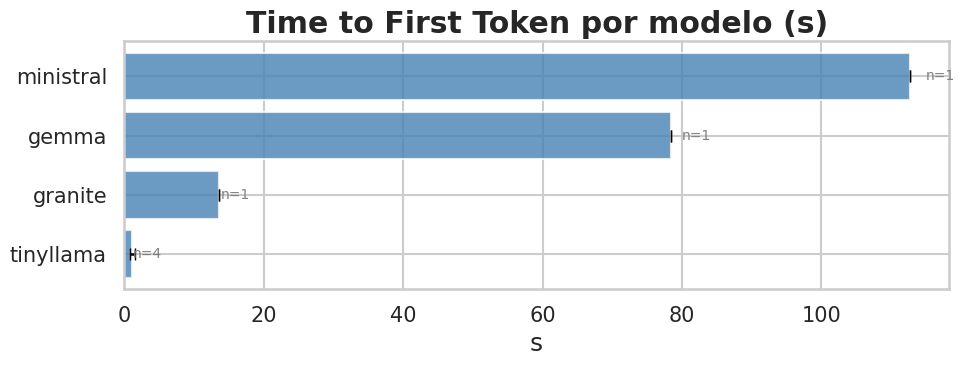

In [4]:
_plot_metric(valid, "time_to_first_token_ms",
             ylabel="TTFT",
             title="Time to First Token por modelo",
             unit_divisor=1000,
             unit_label="s")


## Perplejidad

La perplejidad mide la confianza del modelo sobre los tokens que generó.
Valores bajos (cercanos a 1) indican alta confianza.

**Importante**: la perplejidad **no es comparable** directamente entre
modelos con tokenizers distintos. Sin embargo, sí es comparable entre
ejecuciones del mismo modelo con configuraciones distintas.

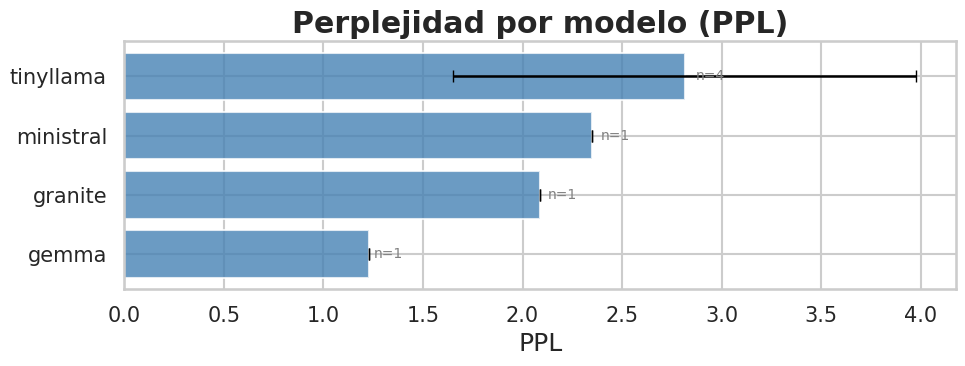

/tmp/ipykernel_413255/3715728501.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")


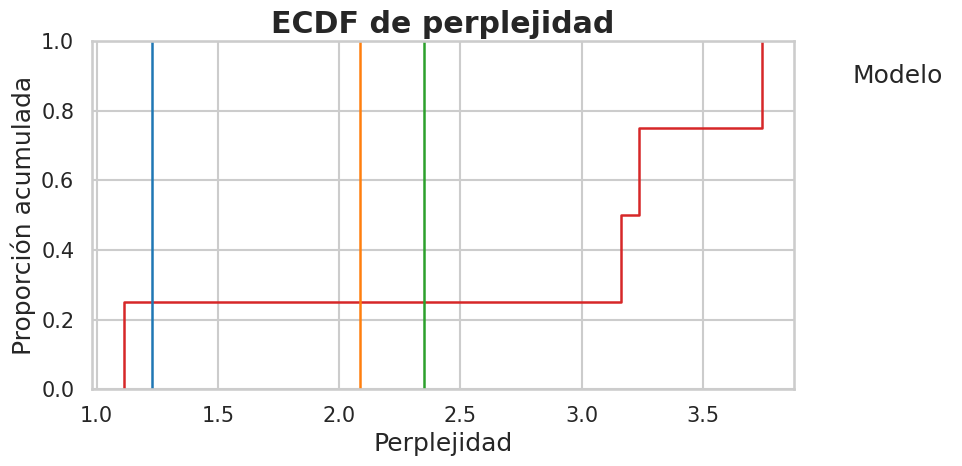

In [5]:
ppl_valid = valid.dropna(subset=["perplexity"])
if ppl_valid.empty:
    print("Sin datos de perplejidad.")
else:
    _plot_metric(ppl_valid, "perplexity",
                 ylabel="PPL",
                 title="Perplejidad por modelo",
                 unit_label="PPL")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
    ax.set_title("ECDF de perplejidad")
    ax.set_xlabel("Perplejidad")
    ax.set_ylabel("Proporción acumulada")
    ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


## Desglose de fases

Proporción del tiempo total que cada prompt pasa en load, prefill y decode.
El decode (generación secuencial token a token) es típicamente >85% del
total en modelos corriendo en CPU.

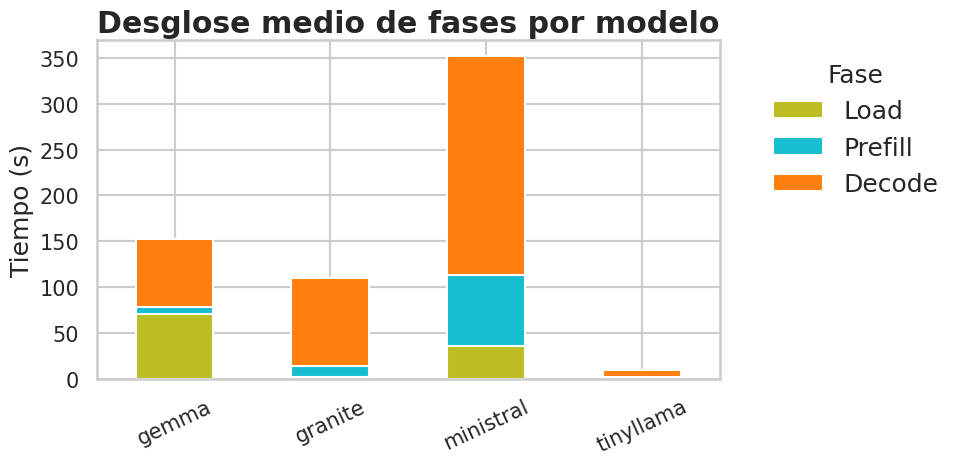

In [6]:
phases = valid.assign(
    Load=valid["load_duration_ns"] / 1e9,
    Prefill=valid["prompt_eval_duration_ns"] / 1e9,
    Decode=valid["eval_duration_ns"] / 1e9,
)
phase_means = (
    phases.groupby("model_label")[["Load", "Prefill", "Decode"]].mean()
)
ax = phase_means.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#bcbd22", "#17becf", "#ff7f0e"],
    rot=25,
)
ax.set_title("Desglose medio de fases por modelo")
ax.set_ylabel("Tiempo (s)")
ax.set_xlabel("")
ax.legend(title="Fase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Tabla resumen

Medias agregadas por modelo con las métricas clave. Esta tabla se puede
copiar directamente a la memoria del TFG.

In [7]:
summary = (
    valid.groupby("model_label")
    .agg(
        n_prompts=("prompt_id", "count"),
        tokens_per_s=("tokens_per_second", "mean"),
        words_per_s=("words_per_second", "mean"),
        latency_s=("latency_ms", lambda x: x.mean() / 1000),
        latency_p95_s=("latency_ms", lambda x: x.quantile(0.95) / 1000),
        ttft_s=("time_to_first_token_ms", lambda x: x.mean() / 1000),
        perplexity=("perplexity", "mean"),
        eval_count_mean=("eval_count", "mean"),
    )
    .round(3)
)
summary


,n_prompts,tokens_per_s,words_per_s,latency_s,latency_p95_s,ttft_s,perplexity,eval_count_mean
model_label,,,,,,,,
gemma,1,5.972,4.713,156.154,156.154,78.444,1.226,441.0
granite,1,4.522,3.786,111.492,111.492,13.510,2.087,436.0
ministral,1,3.553,2.825,355.271,355.271,112.678,2.348,849.0
tinyllama,4,4.597,3.823,8.118,11.505,1.142,2.814,36.5


## Consumo de potencia por fase de inferencia

La inferencia se divide en tres fases con naturaleza computacional distinta:

- **Load**: carga del modelo en RAM. Operación de I/O, bajo consumo.
- **Prefill**: lectura y procesamiento del prompt, construcción del KV-cache.
  Computación paralela (similar a un forward pass completo), pico de consumo.
- **Decode**: generación secuencial token a token. Computación intensiva
  y sostenida, determina el consumo durante la mayor parte del run.

La fase de `load` suele durar <300 ms, menos que el periodo de muestreo
de hardware (~1 s), por lo que la media de potencia durante `load` puede
no tener muestras suficientes para ser fiable (se marca como `NaN`).


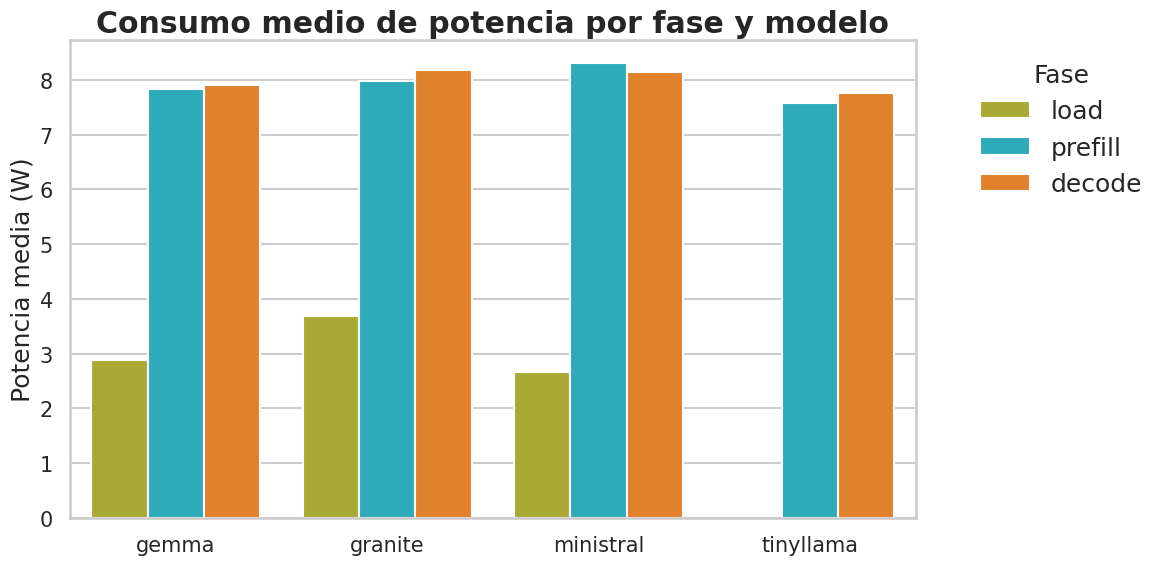


Tabla de potencia media por fase (W):
phase        load  prefill  decode
model_label                       
gemma        2.88     7.83    7.91
granite      3.69     7.98    8.18
ministral    2.66     8.31    8.14
tinyllama     NaN     7.58    7.76


In [8]:
from monitorviz.transforms import power_per_phase_df

phase_df = coll.power_per_phase_df()

# Filter out rows with no hw samples (especially load)
phase_valid = phase_df[
    (phase_df["n_hw_samples"] > 0) &
    (phase_df["power_mean_w"].notna())
].copy()

if phase_valid.empty:
    print("Sin datos de potencia por fase (puede que falten hw runs).")
else:
    # Mean across prompts per (model, phase)
    phase_summary = (
        phase_valid.groupby(["model_label", "phase"])["power_mean_w"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "power_mean_w", "std": "power_std_w", "count": "n_prompts"})
        .reset_index()
    )

    # Bar chart grouped by phase
    phase_order = ["load", "prefill", "decode"]
    phase_summary["phase"] = pd.Categorical(
        phase_summary["phase"], categories=phase_order, ordered=True
    )
    phase_summary = phase_summary.sort_values(["phase", "model_label"])

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=phase_summary, x="model_label", y="power_mean_w",
        hue="phase", hue_order=phase_order,
        palette=["#bcbd22", "#17becf", "#ff7f0e"],
        ax=ax,
    )
    ax.set_title("Consumo medio de potencia por fase y modelo")
    ax.set_xlabel("")
    ax.set_ylabel("Potencia media (W)")
    ax.legend(title="Fase", bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

    # Table
    print("\nTabla de potencia media por fase (W):")
    pivot = phase_summary.pivot(index="model_label", columns="phase", values="power_mean_w").round(2)
    print(pivot.to_string())
